## Setup

### Import Libraries

In [110]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from tqdm import tqdm

from torchvision import datasets
from torchvision import transforms

from pathlib import Path

from torch.utils.data import random_split

### Utility Functions

In [131]:
def create_model(n_features, hidden_layer_size: int = 64, SEED=2026) -> nn.Sequential:
    # create model
    torch.manual_seed(SEED)

    n_classes = 10
    model = nn.Sequential(
        nn.Linear(n_features, hidden_layer_size),
        nn.ReLU(),
        nn.Linear(hidden_layer_size, n_classes),
    )
    return model

def create_deep_model(n_features, hidden_layer_sizes: list[int] = [1024, 512, 256, 128, 64, 32], SEED=2026) -> nn.Sequential:
    # create model
    torch.manual_seed(SEED)

    n_classes = 10

    layers = []
    input_size = n_features

    for hidden_layer_size in hidden_layer_sizes:
        layers.append(nn.Linear(input_size, hidden_layer_size))
        layers.append(nn.ReLU())
        input_size = hidden_layer_size

    layers.append(nn.Linear(input_size, n_classes))

    model = nn.Sequential(*layers)
    return model

def train(model: nn.Module, features_train: torch.Tensor, labels_train: torch.Tensor, learning_rate = 0.01, nepochs = 50) -> None:

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):
        optimizer.zero_grad()

        output = model.forward(features_train)

        loss = loss_function(output, labels_train)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())
        accuracy = utils.calculate_accuracy(model, features_train, labels_train, verbose = False)
        accuracies.append(accuracy)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss:.2f}, Train accuracy: {accuracy:.2f}")


    return losses, accuracies

def calculate_accuracy(model: nn.Module, features: torch.Tensor, labels: torch.Tensor, verbose = True) -> torch.Tensor:

    output = model(features)
    accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
    if verbose:
        print(f'Accuracy: {(accuracy*100).item()}')
    return (accuracy*100).item()

class utils:
    create_model = create_model
    create_deep_model = create_deep_model
    train = train
    calculate_accuracy = calculate_accuracy

### Download Data

In [112]:
mean_cifar10 = (0.4914, 0.4822, 0.4465)
std_cifar10 = (0.2023, 0.1994, 0.2010)

# NOTE: Look up how the mean and std values for normalization are calculated exactly. Simply mean and std across all pixels and images in dataset?
train_data = datasets.CIFAR10(
    download=False,
    root="data",
    train=True,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

test_data = datasets.CIFAR10(
    download=False,
    root="data",
    train=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

In [113]:
labels_train = torch.tensor(train_data.targets)
labels_train

tensor([6, 9, 9,  ..., 9, 1, 1])

In [114]:
# Flatten images: (50000, 32, 32, 3) -> (50000, 3072)
# Normalize pixel values from [0, 255] to [0, 1]
features_train = (torch.tensor(train_data.data, dtype=torch.float32).flatten(start_dim=1) / 255.0)[:10000]
features_test = (torch.tensor(test_data.data, dtype=torch.float32).flatten(start_dim=1) / 255.0)[:2000]
labels_test = torch.tensor(test_data.targets)[:2000]
labels_train = labels_train[:10000]

print(f"features_train shape: {features_train.shape}")
print(f"features_test shape: {features_test.shape}")
print(f"features_train min/max: {features_train.min():.2f} / {features_train.max():.2f}")

features_train shape: torch.Size([10000, 3072])
features_test shape: torch.Size([2000, 3072])
features_train min/max: 0.00 / 1.00


## Section 1: Effect of Making Networks Wider

In [130]:
n_features = 32 * 32 * 3  # CIFAR-10 images flattened
n_classes = 10  # CIFAR-10 has 10 classes

model = utils.create_model(n_features=n_features, hidden_layer_size=100)

losses, accuracies = utils.train(model, features_train, labels_train, nepochs=1000)

  0%|          | 2/1000 [00:00<02:19,  7.14it/s]

Epoch: 0, Loss: 2.32, Train accuracy: 10.05


  1%|          | 11/1000 [00:02<05:04,  3.25it/s]

Epoch: 10, Loss: 4.36, Train accuracy: 11.51


  2%|▏         | 21/1000 [00:05<04:06,  3.97it/s]

...

 98%|█████████▊| 981/1000 [04:34<00:04,  4.56it/s]

Epoch: 980, Loss: 1.72, Train accuracy: 36.52


 99%|█████████▉| 992/1000 [04:37<00:01,  4.58it/s]

Epoch: 990, Loss: 1.72, Train accuracy: 36.66


100%|██████████| 1000/1000 [04:39<00:00,  3.58it/s]


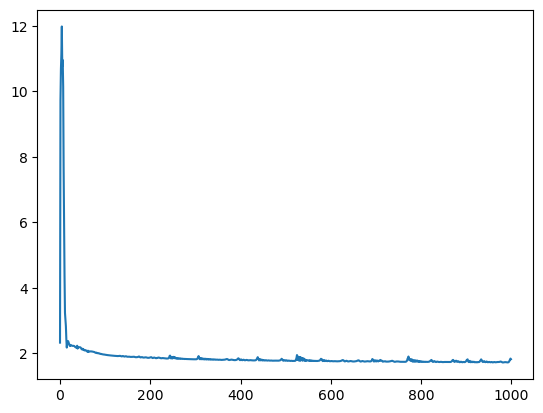

In [132]:
plt.plot(losses)

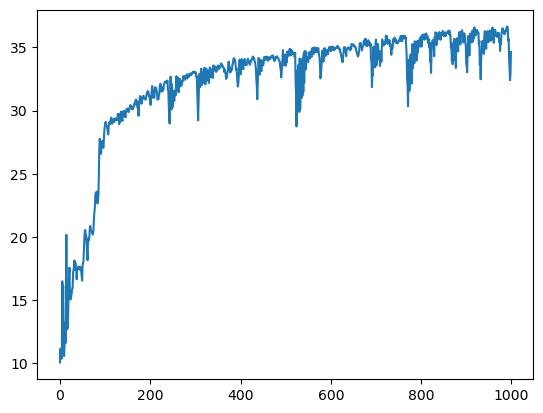

In [133]:
plt.plot(accuracies)

In [134]:
accuracy = utils.calculate_accuracy(model, features_test, labels_test)
print(f"Epoch: {epoch}, Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Accuracy: 31.0
Epoch: 19, Loss: 2.26, accuracy: 31.00


## Section 2: Effect of Making Networks Deeper

In [137]:
n_features = 32 * 32 * 3  # CIFAR-10 images flattened

model = utils.create_deep_model(n_features=n_features, hidden_layer_sizes = [20]*5)

losses_deep, accuracies_deep = utils.train(model, features_train, labels_train, nepochs=1000)

  0%|          | 4/1000 [00:00<01:09, 14.24it/s]

Epoch: 0, Loss: 2.31, Train accuracy: 10.38


  1%|▏         | 14/1000 [00:00<01:00, 16.34it/s]

Epoch: 10, Loss: 2.23, Train accuracy: 17.78


  2%|▏         | 22/1000 [00:01<01:24, 11.59it/s]

...

 98%|█████████▊| 983/1000 [01:55<00:01, 10.23it/s]

Epoch: 980, Loss: 1.41, Train accuracy: 45.19


 99%|█████████▉| 993/1000 [01:56<00:00, 10.75it/s]

Epoch: 990, Loss: 1.42, Train accuracy: 47.08


100%|██████████| 1000/1000 [01:57<00:00,  8.54it/s]


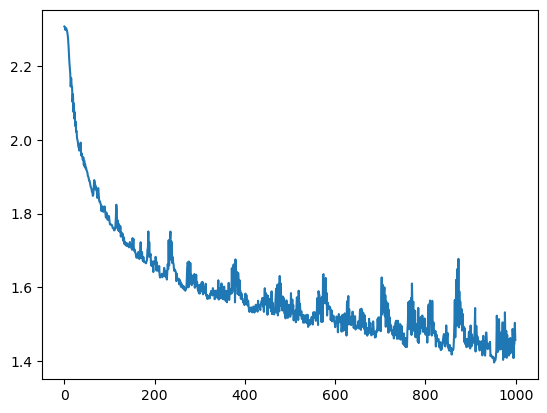

In [138]:
plt.plot(losses_deep)

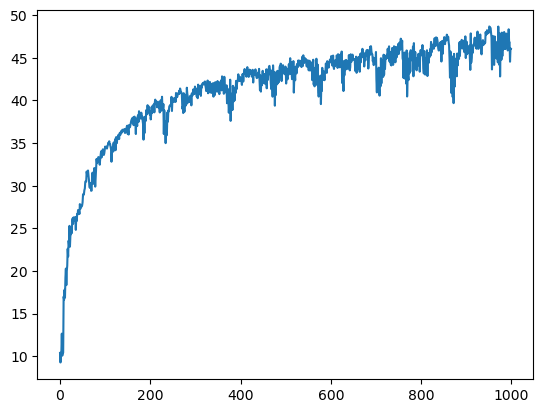

In [140]:
plt.plot(accuracies_deep)

In [141]:
accuracy = utils.calculate_accuracy(model, features_test, labels_test)
print(f"Epoch: {epoch}, Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Accuracy: 36.14999771118164
Epoch: 19, Loss: 2.26, accuracy: 36.15


## Section 3: Batch Normalization

## Section 4: Initialization Matters